In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import rcParams

In [2]:
bias_type = "none"
bias_strength = "0.0"
dataset = "gbs_allensbach"
method = "fw-mrs-temperature"
fixed_hyperparameter = "0.01"

In [3]:
overlapping_allensbach_columns = [
        "Age",
        "Occupational Group",
        "Employment Status",
        "Sex",
        "Optimism",
        "Pessimism",
        "School Degree",
        "Weekly Working Hours",
        "Resilience",
    ]

In [4]:
method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
feature_importances/feature_importances.json")
with open(method_path) as file:
    method_feature_importance_list = np.array(json.load(file))

In [5]:
feature_importances = []
for method_feature_importance in method_feature_importance_list:
    feature_importances.append(method_feature_importance["0.0"][fixed_hyperparameter])

In [6]:
feature_importances_df = pd.DataFrame(feature_importances)
feature_importances_df.columns = overlapping_allensbach_columns
order = feature_importances_df[overlapping_allensbach_columns].mean().sort_values(ascending=False).index

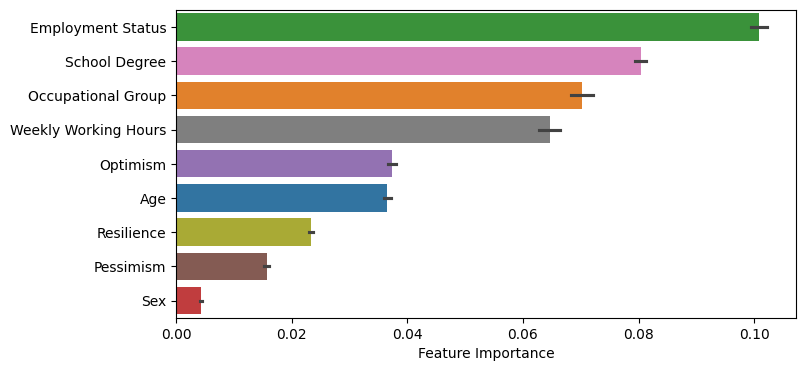

In [7]:
# figure size in inches
rcParams['figure.figsize'] = 8,4

ax = sns.barplot(feature_importances_df, orient="y", order=order)
ax.set(xlabel="Feature Importance")
ax.get_figure().savefig("gbs_allensbach_feature_importances.pdf", bbox_inches='tight') 

In [8]:
method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
feature_weights/weights.json")
with open(method_path) as file:
    method_feature_weights_list = np.array(json.load(file))

In [9]:
feature_weights = []
for method_feature_weights in method_feature_weights_list:
    for key in method_feature_weights.keys():
        feature_weights.append(method_feature_weights[key][fixed_hyperparameter])

In [10]:
feature_weights_df = pd.DataFrame(feature_weights)
feature_weights_df.columns = overlapping_allensbach_columns
feature_weights_df["Temperature"] = np.array([list(method_feature_weights.keys()) for method_feature_weights in method_feature_weights_list]).flatten().astype(float)
order = feature_weights_df[overlapping_allensbach_columns].mean().sort_values(ascending=False).index

In [11]:
melted_feature_weights_df = pd.melt(feature_weights_df, id_vars="Temperature", value_vars=overlapping_allensbach_columns)
melted_feature_weights_df["Temperature"] = melted_feature_weights_df["Temperature"].astype("category")

In [12]:
melted_feature_weights_df

,Temperature,variable,value
0,0.0000,Age,1.111111e-01
1,0.5000,Age,1.132597e-01
2,0.2500,Age,1.150048e-01
3,0.1000,Age,1.177459e-01
4,0.0500,Age,1.144832e-01
...,...,...,...
535,0.0250,Resilience,1.639861e-01
536,0.0100,Resilience,9.655250e-02
537,0.0050,Resilience,1.943442e-02
538,0.0025,Resilience,4.627371e-04


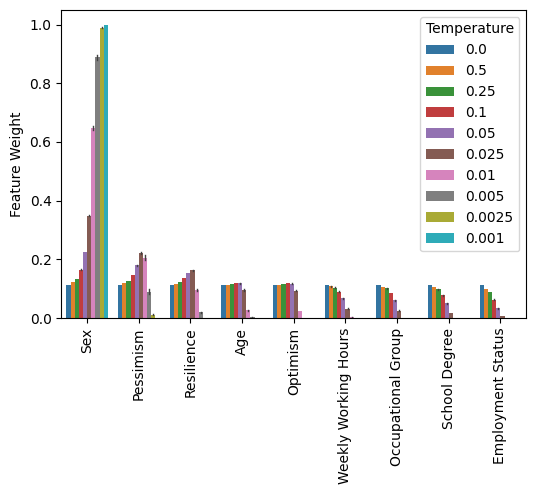

In [24]:
hue_order = [0.0, 0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.005, 0.0025, 0.001]
rcParams['figure.figsize'] = 6,4

ax = sns.barplot(melted_feature_weights_df, y="value", x="variable", hue="Temperature", order=order,
                 hue_order=hue_order, err_kws={'linewidth': 1})
ax.set(ylabel="Feature Weight", xlabel="")
ax.tick_params(axis='x', rotation=90)
ax.get_figure().savefig("gbs_allensbach_feature_weights.pdf", bbox_inches='tight') 